# 📚 Chapter 2: The Bootstrap

## 🔄 Quick Revision

- **Bootstrap** is a resampling technique used to estimate the **sampling distribution** of a statistic.
- It works by repeatedly **sampling with replacement** from the **original sample**.
- The bootstrap is useful when the **population is unknown** and collecting new samples is impractical.
- Each bootstrap sample has the **same size** as the original sample.
- Because sampling is done **with replacement**, some observations may appear multiple times while others may not appear at all.
- After many bootstrap resamples, the resulting statistics form the **bootstrap distribution**.
- The bootstrap distribution can be used to estimate:
  - **Standard Error**
  - **Confidence Intervals**
  - **Sampling Distribution**
- Bootstrap is a **computational method** and does **not require the Central Limit Theorem** or normality assumptions in many situations.
- **Bootstrap does not create new information**; it only estimates how the statistic would vary if similar samples were collected.

---

## 📖 Important Terms

| Term | Meaning |
|------|---------|
| **Bootstrap Sample** | A sample drawn **with replacement** from the original observed sample. |
| **Resampling** | Repeatedly drawing samples from the observed data. Includes bootstrap and permutation methods. |
| **Bootstrap Distribution** | Distribution of a statistic computed from many bootstrap samples. |
| **Iteration (R)** | Number of bootstrap resamples performed (e.g., 1000 or more). |
| **Bagging (Bootstrap Aggregating)** | Training multiple models on bootstrap samples and combining their predictions to improve performance. |

---

## 🎯 Bootstrap Algorithm

```text
Original Sample
      │
      ▼
Draw Bootstrap Sample
(with replacement)
      │
      ▼
Compute Statistic
(e.g., Mean, Median)
      │
      ▼
Store Statistic
      │
Repeat R times
      │
      ▼
Bootstrap Distribution
      │
      ├── Estimate Standard Error
      ├── Estimate Confidence Interval
      └── Study Sampling Variability
```

---

## 🎯 Why Sampling With Replacement?

Without replacement:

```
A B C D E
```

Every resample would contain the same observations, so the statistic would barely change.

With replacement:

```
A A C E B

B D D A E

E E C A A
```

Each resample is different, allowing the statistic to vary and the sampling distribution to be estimated.

---

## 🎯 Bootstrap vs Sampling Distribution

| Sampling Distribution | Bootstrap Distribution |
|------------------------|------------------------|
| Obtained by repeatedly sampling from the **population** | Obtained by repeatedly sampling from the **original sample** |
| Usually theoretical or impossible to observe directly | Practical approximation using available data |
| Assumes access to the population | Requires only one observed sample |

---

## 🎯 Standard Error via Bootstrap

Instead of using

$$
SE=\frac{s}{\sqrt{n}}
$$

Bootstrap estimates the Standard Error by:

1. Generating many bootstrap samples.
2. Computing the statistic for each sample.
3. Calculating the **standard deviation** of those statistics.

This standard deviation is the **bootstrap estimate of the Standard Error**.

---

## 🤖 Bootstrap in Machine Learning

Bootstrap is widely used in Machine Learning.

A famous application is:

**Bagging (Bootstrap Aggregating)**

Process:

- Create many bootstrap samples.
- Train one model on each sample.
- Combine their predictions.

This reduces variance and improves model stability.

**Random Forest** is a classic example built using bagging.

---

## ⚠️ Common Misconceptions

❌ Bootstrap **does NOT**:

- Create new data.
- Increase the sample size.
- Correct a biased or poor-quality sample.
- Compensate for an unrepresentative dataset.

✅ Bootstrap **DOES**:

- Estimate sampling variability.
- Estimate Standard Error.
- Estimate Confidence Intervals.
- Approximate the sampling distribution using only the available sample.

---

## 🧠 Memory Flow

```text
Unknown Population
        │
        ▼
One Observed Sample
        │
Treat as Temporary Population
        │
        ▼
Bootstrap Resampling
(with replacement)
        │
        ▼
Many Sample Statistics
        │
        ▼
Bootstrap Distribution
        │
        ▼
Estimate SE, Confidence Intervals,
and Sampling Variability
```

---

## 💡 Key Takeaways

- **Sampling Distribution** asks:
  > *"What would happen if we repeatedly sampled from the population?"*

- **Bootstrap** answers:
  > *"Since we don't have the population, let's repeatedly sample from our observed sample instead."*

- Bootstrap replaces mathematical assumptions with **computation**, making it one of the most powerful and widely used techniques in modern statistics and machine learning.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [2]:
population = np.random.exponential(scale = 50, size = 10000)

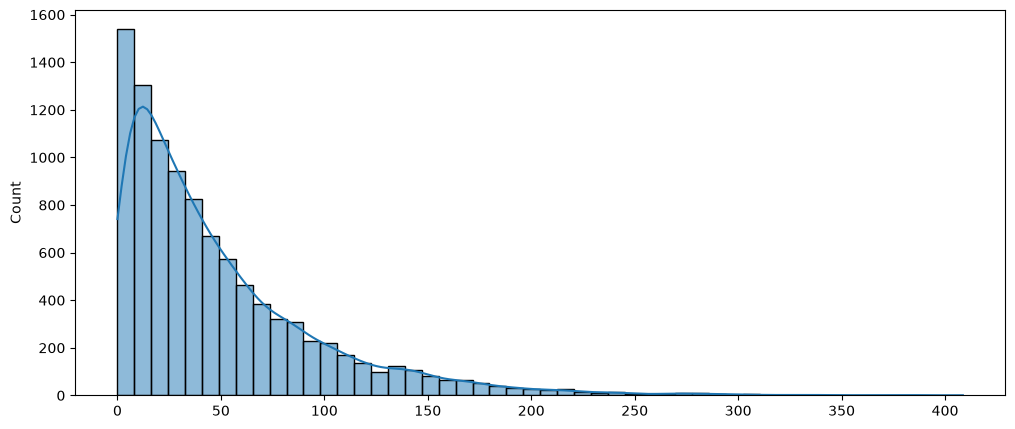

In [3]:
plt.figure(figsize = (12, 5))
sns.histplot(
    population,
    bins = 50,
    kde = True
)
plt.show()

In [5]:
# Imagine the original population is hidden
# Taking a sample 

sample = np.random.choice(
            population,
            size = 100,
            replace=False
)

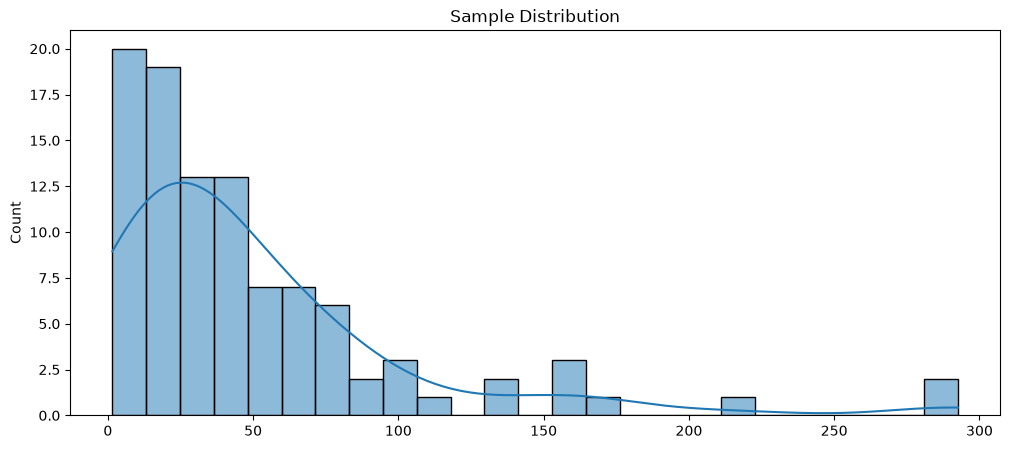

In [7]:
plt.figure(figsize = (12, 5))
sns.histplot(
    sample,
    bins = 25,
    kde = True
)

plt.title("Sample Distribution")
plt.show()

In [8]:
sample.mean()

np.float64(49.936551035824294)

# Bootstrapping Sample 

In [9]:
bootstrap = np.random.choice(
                sample,
                size = 100,
                replace = True
)

In [10]:
print(bootstrap[:20])
print()
print(sample[:20])

[ 34.61921478  41.57382683  35.43922424 139.50554375 162.10741058
   6.78370307  71.5142578   64.60858808  37.71332723  15.60308549
  23.72783604  32.28027367  69.79890149  21.49870982   6.78370307
  35.43922424  29.10483449   6.78370307  13.84908829  86.18010102]

[ 52.3050304   61.83708497 139.50554375  16.45681506  56.16363905
   2.60963066   8.6155743    9.41774318  24.60651459  12.08421159
   9.24120057  30.46942963   3.99563426   1.57804897  46.8919714
  10.48291292  29.10483449  17.01234824  35.43922424  16.55989045]


In [13]:
print(sample.mean())
print(bootstrap.mean())

49.936551035824294
58.413540117226994


In [14]:
def bootstrap_means(sample, n_bootstrap):
    means = []

    for _ in range(n_bootstrap):
        temp = np.random.choice(
            sample,
            size = len(sample),
            replace=True
        )
        means.append(temp.mean())
    return means

In [16]:
s_means = bootstrap_means(sample, 1000)

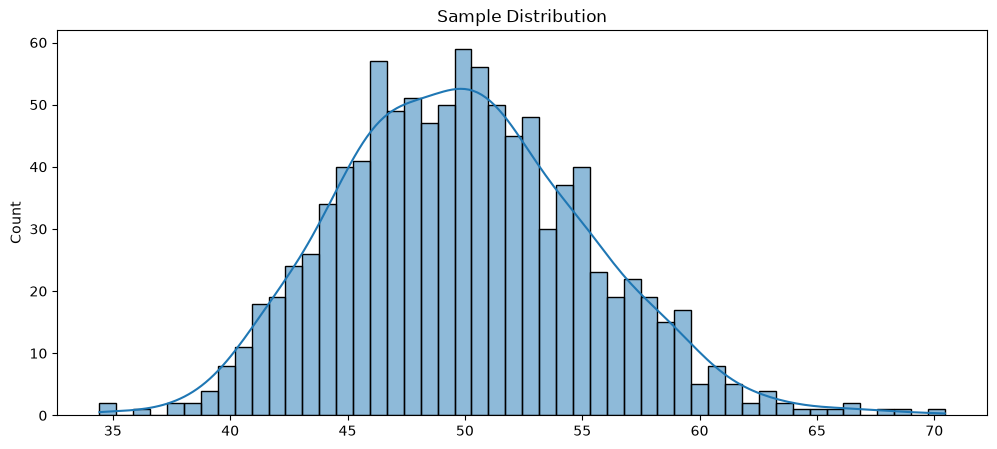

In [18]:
plt.figure(figsize = (12, 5))
sns.histplot(
    s_means,
    bins = 50,
    kde = True
)

plt.title("Sample Distribution")
plt.show()